<!-- @q -->
## Problem 1 

Using the data in the `2019_Yellow_Taxi_Trip_Data.csv` file, calculate summary statistics for the `fare_amount`, `tip_amount`, `tolls_amount`, and `total_amount` columns:

In [50]:
import pandas as pd

taxi = pd.read_csv("data/2019_Yellow_Taxi_Trip_Data.csv")

taxi[['fare_amount', 'tip_amount', 'tolls_amount', 'total_amount']].describe()

,fare_amount,tip_amount,tolls_amount,total_amount
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,15.106313,2.634494,0.623447,22.564659
std,13.954762,3.409800,6.437507,19.209255
min,-52.000000,0.000000,-6.120000,-65.920000
25%,7.000000,0.000000,0.000000,12.375000
50%,10.000000,2.000000,0.000000,16.300000
75%,16.000000,3.250000,0.000000,22.880000
max,176.000000,43.000000,612.000000,671.800000


<!-- @q -->
## Problem 2

Isolate the `fare_amount`, `tip_amount`, `tolls_amount`, and `total_amount` for the longest trip by distance (`trip_distance`):

In [49]:
taxi.loc[taxi['trip_distance'].idxmax(), ['fare_amount', 'tip_amount', 'tolls_amount', 'total_amount']]

fare_amount      176.0
tip_amount       18.29
tolls_amount      6.12
total_amount    201.21
Name: 2019-10-24 15:32:55, dtype: object

<!-- @q -->
## Problem 3 

Read in the meteorite data from the `Meteorite_Landings.csv` file, rename the `mass (g)` column to `mass`, and drop all the latitude and longitude columns. Sort the result by mass in descending order.

In [48]:
meteorites = pd.read_csv("data/Meteorite_Landings.csv")

meteorites = meteorites.rename(columns={'mass (g)': 'mass'})

meteorites = meteorites.drop(columns=['reclat', 'reclong'])

meteorites_sorted = meteorites.sort_values(by='mass', ascending=False)

print(meteorites_sorted.head())

                  name     id nametype      recclass        mass   fall  \
16392             Hoba  11890    Valid     Iron, IVB  60000000.0  Found   
5373         Cape York   5262    Valid   Iron, IIIAB  58200000.0  Found   
5365   Campo del Cielo   5247    Valid  Iron, IAB-MG  50000000.0  Found   
5370     Canyon Diablo   5257    Valid  Iron, IAB-MG  30000000.0  Found   
3455           Armanty   2335    Valid    Iron, IIIE  28000000.0  Found   

                         year             GeoLocation  
16392  01/01/1920 12:00:00 AM   (-19.58333, 17.91667)  
5373   01/01/1818 12:00:00 AM   (76.13333, -64.93333)  
5365   12/22/1575 12:00:00 AM  (-27.46667, -60.58333)  
5370   01/01/1891 12:00:00 AM     (35.05, -111.03333)  
3455   01/01/1898 12:00:00 AM            (47.0, 88.0)  


<!-- @q -->
## Problem 4

Using the meteorite data from the `Meteorite_Landings.csv` file, update the `year` column to only contain the year, convert it to a numeric data type, and create a new column indicating whether the meteorite was observed falling before 1970. Set the index to the `id` column and extract all the rows with IDs between 10,036 and 10,040 (inclusive) with `loc[]`.

**Hint 1**: Use `year.str.slice()` to grab a substring.

**Hint 2**: Make sure to sort the index before using `loc[]` to select the range.

In [47]:
meteorites['year'] = meteorites['year'].str.slice(6,10)

meteorites['year'] = pd.to_numeric(meteorites['year'])

meteorites['before_1970'] = meteorites['year'] < 1970 

meteorites = meteorites.set_index('id').sort_index()

meteorites.loc[10036:10040]

,name,nametype,recclass,mass,fall,year,GeoLocation,before_1970
id,,,,,,,,
10036,Enigma,Valid,H4,94.0,Found,1967.0,"(31.33333, -82.31667)",True
10037,Enon,Valid,"Iron, ungrouped",763.0,Found,1883.0,"(39.86667, -83.95)",True
10038,Enshi,Valid,H5,8000.0,Fell,1974.0,"(30.3, 109.5)",False
10039,Ensisheim,Valid,LL6,127000.0,Fell,1491.0,"(47.86667, 7.35)",True


**BONUS**: There's a data entry error in the `year` column. Can you find it?

In [8]:
future_meteorites = meteorites[meteorites['year'] > 2025]
print(future_meteorites)


                          id nametype recclass  mass   fall    year  \
name                                                                  
Northwest Africa 7701  57150    Valid      CK6  55.0  Found  2101.0   

                      GeoLocation  pre_1970  
name                                         
Northwest Africa 7701  (0.0, 0.0)     False  


There's a meteorite that was reportedly found in the future:

In [9]:
# Your code here


_This meteorite actually was found in 2010 (more information [here](https://www.lpi.usra.edu/meteor/metbull.php?code=57150))._

<!-- @q -->
## Problem 5

Using the taxi trip data in the `2019_Yellow_Taxi_Trip_Data.csv` file, resample the data to an hourly frequency based on the dropoff time. Calculate the total `trip_distance`, `fare_amount`, `tolls_amount`, and `tip_amount`, then find the 5 hours with the most tips.

In [36]:
taxi = pd.read_csv('data/2019_Yellow_Taxi_Trip_Data.csv')

taxi['tpep_dropoff_datetime'] = pd.to_datetime(taxi["tpep_dropoff_datetime"])

taxi.set_index('tpep_dropoff_datetime', inplace=True)

hourly_freq = taxi[['trip_distance', 'fare_amount', 'tolls_amount', 'tip_amount']]

print(hourly_freq.head(5))

hourly_freq.sort_values(by='tip_amount', ascending=False).head(5)

                       trip_distance  fare_amount  tolls_amount  tip_amount
tpep_dropoff_datetime                                                      
2019-10-23 17:14:10             7.93         29.5          6.12        7.98
2019-10-23 16:45:26             2.00         10.5          0.00        0.00
2019-10-23 16:21:11             1.36          9.5          0.00        2.00
2019-10-23 16:43:26             1.00         13.0          0.00        4.32
2019-10-23 16:58:49             1.96         10.5          0.00        0.50


,trip_distance,fare_amount,tolls_amount,tip_amount
tpep_dropoff_datetime,,,,
2019-10-23 16:30:00,2.80,12.5,0.0,43.00
2019-10-23 16:15:32,0.00,2.5,0.0,40.00
2019-10-23 18:58:16,19.50,96.0,27.0,37.25
2019-10-23 16:52:02,0.05,2.5,0.0,36.00
2019-10-23 16:11:22,0.76,5.0,0.0,30.03


<!-- @q -->
## Problem 6

Using the TSA traveler throughput data in the `tsa_melted_holiday_travel.csv` file, create box plots for traveler throughput for each year in the data. Hint: Pass `kind='box'` into the `plot()` method to generate box plots.

<Axes: title={'center': 'travelers'}, xlabel='year'>

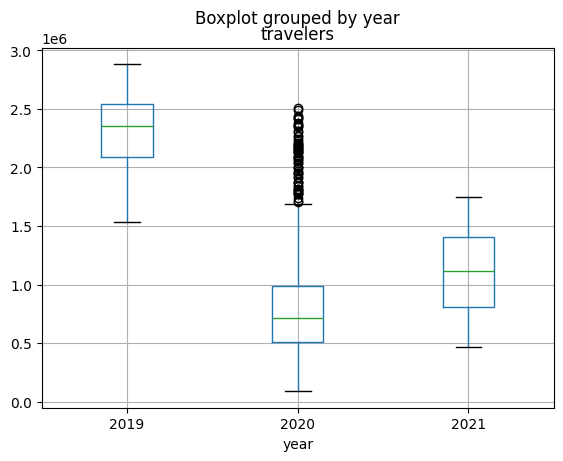

In [15]:
tsa = pd.read_csv('data/tsa_melted_holiday_travel.csv')
tsa.boxplot(column= 'travelers', by= 'year')


<!-- @q -->
## Problem 7
Using the TSA traveler throughput data in the `tsa_melted_holiday_travel.csv` file, create a heatmap that shows the 2019 TSA median traveler throughput by day of week and month.

/tmp/ipykernel_2911/1041564759.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tsa_2019['date']  = pd.to_datetime(tsa_2019['date'])
/tmp/ipykernel_2911/1041564759.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tsa_2019['month'] = tsa_2019['date'].dt.month_name()
/tmp/ipykernel_2911/1041564759.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.p

<Axes: xlabel='month', ylabel='day'>

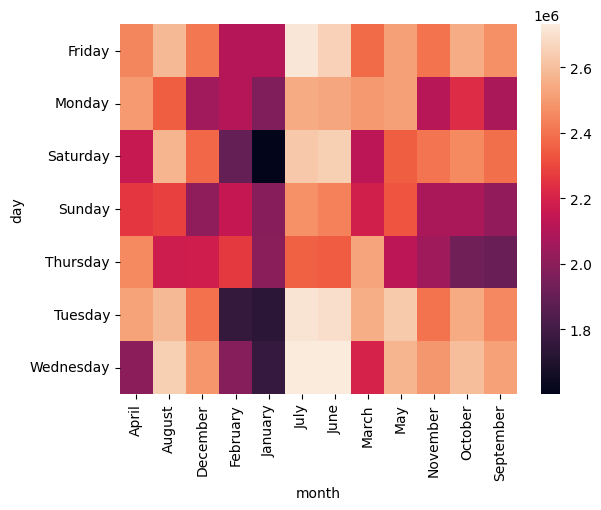

In [ ]:
import pandas as pd

tsa1 = pd.read_csv("data/tsa_melted_holiday_travel.csv")

tsa_2019 = tsa1[tsa1["year"] == 2019]
tsa_2019['date']  = pd.to_datetime(tsa_2019['date'])
tsa_2019['month'] = tsa_2019['date'].dt.month_name()
tsa_2019['day'] = tsa_2019['date'].dt.day_name()
median_travelers = tsa_2019.groupby(['month', 'day'])['travelers'].median().reset_index()
median_travelers

import seaborn as sns


heatmap_data = median_travelers.pivot(index='day', columns='month', values='travelers')
sns.heatmap(heatmap_data)

